# Analisis Operasional Pengiriman JNE

**Capstone Project Module 3 — Business & Data Analyst**

## Latar Belakang

JNE menangani ratusan ribu paket. Analisis ini mencari sumber masalah operasional terbesar dan menentukan tindakan perbaikan yang tepat.

## Business Questions

1. Cabang atau sorting hub mana yang menjadi bottleneck keterlambatan?
2. Bagaimana perbandingan RTS antara COD dan Non-COD?
3. Seberapa besar estimasi kebocoran pendapatan akibat anomali berat paket?
4. Layanan mana yang paling tidak konsisten penulisannya?
5. Berapa banyak paket berstatus Delivered yang memiliki `delivered_date` sebelum `pickup_date`?
6. Berapa persentase data pengirim yang kosong dan menghambat cross-selling?

## Data

Analisis menggunakan tiga tabel periode **Mei–Oktober 2023**:

| Tabel | Baris | Keterangan |
|---|---:|---|
| `jne_shipments.csv` | 300.000 | Satu baris per paket |
| `jne_customers.csv` | 30.000 | Data pengirim |
| `jne_branches.csv` | 150 | Data cabang asal |

Tiga tabel digabungkan berdasarkan `sender_id` dan `origin_branch` setelah pemeriksaan dan cleaning.

## 1. Persiapan

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, kruskal

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.bbox'] = 'tight'

# Palet warna konsisten untuk seluruh notebook
WARNA_UTAMA  = '#2E86AB'
WARNA_BAHAYA = '#E74C3C'
WARNA_AMAN   = '#27AE60'
WARNA_NETRAL = '#95A5A6'

In [12]:
ship = pd.read_csv('../data/raw/jne_shipments.csv', parse_dates=['pickup_date', 'delivered_date'])
cust = pd.read_csv('../data/raw/jne_customers.csv')
branch = pd.read_csv('../data/raw/jne_branches.csv')

display(pd.DataFrame({
    'tabel': ['shipments', 'customers', 'branches'],
    'baris': [len(ship), len(cust), len(branch)],
    'kolom': [ship.shape[1], cust.shape[1], branch.shape[1]],
}))

,tabel,baris,kolom
0,shipments,300000,10
1,customers,30000,3
2,branches,150,3


In [13]:
ship.head(),ship.tail()

(     awb_number   sender_id origin_branch   dest_city       service_type payment_type  weight_kg         pickup_date  \
 0  JNE000000001  CUST-25624         B-035  Yogyakarta            Reguler      Prepaid        9.5 2023-05-12 17:00:00   
 1  JNE000000002  CUST-17057         B-054   Palembang                REG          COD       19.5 2023-05-02 15:00:00   
 2  JNE000000003  CUST-27196         B-104  Yogyakarta                YES      Prepaid       14.8 2023-10-25 17:00:00   
 3  JNE000000004  CUST-15447         B-097       Medan                REG      Prepaid       16.3 2023-10-09 09:00:00   
 4  JNE000000005  CUST-20847         B-147    Surabaya  Yakin Esok Sampai      Prepaid        1.1 2023-08-22 09:00:00   
 
        delivered_date     status  
 0 2023-05-18 22:00:00  Delivered  
 1 2023-05-08 00:00:00        RTS  
 2 2023-10-27 19:00:00  Delivered  
 3 2023-10-14 19:00:00  Delivered  
 4 2023-08-24 20:00:00  Delivered  ,
           awb_number   sender_id origin_branch   dest_

## 2. Data Understanding

Sebelum masuk ke analisis, kita perlu mengenal dataset lebih jauh. Dari proses ini kita akan tahu anomali apa saja yang ada di dalam data dan perlu ditangani di tahap *data cleaning*.

Pemeriksaan dilakukan pada empat hal: **struktur & tipe data**, **data kosong**, **data duplikat**, dan **integritas relasi antar tabel**.

In [14]:
ship.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   awb_number      300000 non-null  object        
 1   sender_id       300000 non-null  object        
 2   origin_branch   300000 non-null  object        
 3   dest_city       300000 non-null  object        
 4   service_type    300000 non-null  object        
 5   payment_type    300000 non-null  object        
 6   weight_kg       300000 non-null  float64       
 7   pickup_date     300000 non-null  datetime64[ns]
 8   delivered_date  300000 non-null  datetime64[ns]
 9   status          300000 non-null  object        
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 22.9+ MB


In [15]:
ship.describe(),ship.describe(include='object')

(           weight_kg                    pickup_date                 delivered_date
 count  300000.000000                         300000                         300000
 mean       23.845689  2023-07-30 01:45:31.512000256  2023-08-02 16:13:12.768000256
 min        -5.000000            2023-05-01 08:00:00            2023-04-28 10:00:00
 25%         5.700000            2023-06-15 09:00:00            2023-06-18 19:00:00
 50%        10.500000            2023-07-30 10:00:00            2023-08-02 20:00:00
 75%        15.300000            2023-09-12 18:00:00            2023-09-16 16:00:00
 max      9999.000000            2023-10-27 19:00:00            2023-11-03 06:00:00
 std       350.372839                            NaN                            NaN,
           awb_number   sender_id origin_branch dest_city service_type payment_type     status
 count         300000      300000        300000    300000       300000       300000     300000
 unique        300000       29999           150      

Untuk melihat gambaran menyeluruh, mari kita rangkum setiap kolom: tipe data, jumlah kosong, jumlah nilai unik, dan contoh isinya.

In [16]:
def ringkas_kolom(df, nama):
    baris = []
    for col in df.columns:
        baris.append([
            col,
            df[col].dtype,
            df[col].isna().sum(),
            round(df[col].isna().sum() / len(df) * 100, 2),
            df[col].nunique(),
            df[col].dropna().unique()[:3],
        ])
    return pd.DataFrame(
        baris,
        columns=['kolom', 'tipe', 'n_kosong', 'pct_kosong', 'n_unik', 'contoh_nilai'],
    )

display(ringkas_kolom(ship, 'jne_shipments'))
display(ringkas_kolom(cust, 'jne_customers'))
display(ringkas_kolom(branch, 'jne_branches'))

,kolom,tipe,n_kosong,pct_kosong,n_unik,contoh_nilai
0,awb_number,object,0,0.0,300000,"[JNE000000001, JNE000000002, JNE000000003]"
1,sender_id,object,0,0.0,29999,"[CUST-25624, CUST-17057, CUST-27196]"
2,origin_branch,object,0,0.0,150,"[B-035, B-054, B-104]"
3,dest_city,object,0,0.0,10,"[Yogyakarta, Palembang, Medan]"
4,service_type,object,0,0.0,9,"[Reguler, REG, YES]"
5,payment_type,object,0,0.0,2,"[Prepaid, COD]"
6,weight_kg,float64,0,0.0,195,"[9.5, 19.5, 14.8]"
7,pickup_date,datetime64[ns],0,0.0,2160,"[2023-05-12 17:00:00, 2023-05-02 15:00:00, 202..."
8,delivered_date,datetime64[ns],0,0.0,4282,"[2023-05-18 22:00:00, 2023-05-08 00:00:00, 202..."
9,status,object,0,0.0,4,"[Delivered, RTS, Lost]"


,kolom,tipe,n_kosong,pct_kosong,n_unik,contoh_nilai
0,customer_id,object,0,0.00,30000,"[CUST-00001, CUST-00002, CUST-00003]"
1,city,object,0,0.00,10,"[Makassar, Denpasar, Medan]"
2,customer_type,object,4579,15.26,2,"[Individual, Corporate]"


,kolom,tipe,n_kosong,pct_kosong,n_unik,contoh_nilai
0,branch_code,object,0,0.0,150,"[B-001, B-002, B-003]"
1,branch_name,object,0,0.0,150,"[JNE Cabang Utama 1, JNE Cabang Utama 2, JNE C..."
2,region,object,0,0.0,8,"[Sumatera, Kalimantan, Jabodetabek]"


### 2.1 Data duplikat dan integritas relasi

Dua hal yang wajib diperiksa sebelum analisis: apakah ada baris ganda, dan apakah semua kunci relasi (*foreign key*) punya pasangan di tabel dimensi. Kalau ada `sender_id` yang tidak terdaftar di tabel customer, hasil penggabungan tabel nanti akan bocor menjadi data kosong.

In [17]:
sender_orphan = (~ship.sender_id.isin(cust.customer_id)).sum()
branch_orphan = (~ship.origin_branch.isin(branch.branch_code)).sum()

display(pd.Series({
    'awb_number ganda': ship.awb_number.duplicated().sum(),
    'customer_id ganda': cust.customer_id.duplicated().sum(),
    'branch_code ganda': branch.branch_code.duplicated().sum(),
    'baris shipment identik': ship.duplicated().sum(),
    'sender_id tanpa pasangan': sender_orphan,
    'origin_branch tanpa pasangan': branch_orphan,
    'awal periode pickup': ship.pickup_date.min(),
    'akhir periode pickup': ship.pickup_date.max(),
    'rentang hari': (ship.pickup_date.max() - ship.pickup_date.min()).days,
}).rename('nilai').to_frame())

,nilai
awb_number ganda,0
customer_id ganda,0
branch_code ganda,0
baris shipment identik,0
sender_id tanpa pasangan,0
origin_branch tanpa pasangan,0
awal periode pickup,2023-05-01 08:00:00
akhir periode pickup,2023-10-27 19:00:00
rentang hari,179


Hasilnya bersih: **tidak ada duplikat** di ketiga tabel, dan **integritas relasi utuh** — seluruh 300.000 `sender_id` dan `origin_branch` punya pasangan yang valid. Artinya penggabungan tabel nanti aman, tidak akan menghasilkan data kosong baru.

Periode data mencakup 179 hari, dari 1 Mei sampai 27 Oktober 2023.

### 2.2 Data kosong

Selanjutnya, mari kita periksa data kosong di setiap tabel.

In [18]:
display(pd.DataFrame({
    'shipments': ship.isna().sum(),
    'customers': cust.isna().sum(),
    'branches': branch.isna().sum(),
}).fillna(0).astype(int))

,shipments,customers,branches
awb_number,0,0,0
branch_code,0,0,0
branch_name,0,0,0
city,0,0,0
customer_id,0,0,0
customer_type,0,4579,0
delivered_date,0,0,0
dest_city,0,0,0
origin_branch,0,0,0
payment_type,0,0,0


Hanya satu kolom yang punya data kosong: **`customer_type` di tabel customers, sebanyak 4.579 baris (15,26%)**. Tabel shipments dan branches sepenuhnya terisi.

Proporsi 15% terlalu besar untuk dibuang begitu saja — membuang 4.579 pelanggan berarti membuang 15% basis analisis segmentasi. Kita akan tangani ini di tahap cleaning setelah memastikan pola kekosongannya.

### 2.3 Konsistensi penulisan kategori

Kolom kategorikal sering menyimpan masalah tersembunyi: satu kategori yang sama ditulis dengan beberapa cara berbeda. Mari kita periksa.

In [19]:
display(pd.concat({
    'service_type': ship.service_type.value_counts(),
    'payment_type': ship.payment_type.value_counts(),
    'status': ship.status.value_counts(),
}, axis=1).fillna(0).astype(int))

,service_type,payment_type,status
REG,89984,0,0
YES,44981,0,0
OKE,30140,0,0
oke,30061,0,0
Reguler,29943,0,0
reg,29908,0,0
Yakin Esok Sampai,15099,0,0
yes,14960,0,0
Ongkos Kirim Ekonomis,14924,0,0
Prepaid,0,195091,0


Masalah ditemukan. Kolom **`service_type` punya 9 varian penulisan**, padahal JNE hanya memiliki 3 jenis layanan:

| Layanan resmi | Varian di database |
|---|---|
| **REG** (Reguler) | `REG`, `reg`, `Reguler` |
| **YES** (Yakin Esok Sampai) | `YES`, `yes`, `Yakin Esok Sampai` |
| **OKE** (Ongkos Kirim Ekonomis) | `OKE`, `oke`, `Ongkos Kirim Ekonomis` |

Pola ini menunjukkan tiga sumber input yang berbeda: satu memakai huruf kapital, satu huruf kecil, satu menulis nama panjang. Kalau dibiarkan, analisis per layanan akan memecah satu layanan menjadi tiga kelompok terpisah.

Sementara `payment_type` dan `status` sudah konsisten — tidak perlu penanganan.

### 2.4 Distribusi berat paket

Kolom `weight_kg` adalah satu-satunya kolom numerik selain tanggal. Mari kita periksa sebarannya.

In [20]:
display(ship.weight_kg.describe().to_frame('weight_kg'))

display(pd.Series({
    'berat <= 0 kg': (ship.weight_kg <= 0).sum(),
    'berat > 100 kg': (ship.weight_kg > 100).sum(),
}).rename('jumlah').to_frame())

display(pd.DataFrame({
    '<= 0 kg': pd.Series(sorted(ship.loc[ship.weight_kg <= 0, 'weight_kg'].unique())),
    '> 100 kg': pd.Series(sorted(ship.loc[ship.weight_kg > 100, 'weight_kg'].unique())),
}))

,weight_kg
count,300000.000000
mean,23.845689
std,350.372839
min,-5.000000
25%,5.700000
50%,10.500000
75%,15.300000
max,9999.000000


,jumlah
berat <= 0 kg,769
berat > 100 kg,731


,<= 0 kg,> 100 kg
0,-5.0,999.0
1,-1.5,9999.0


Temuan ini perlu diperhatikan.

Nilai `weight_kg` berkisar dari **-5 kg** sampai **9.999 kg**, padahal nilai tersebut tidak masuk akal secara fisik. Hanya empat nilai yang berulang pada wilayah anomali, sehingga nilai tersebut kemungkinan merupakan **nilai penanda dari sistem**.

Masalah ini akan dibahas lebih lanjut pada Pertanyaan 3.

In [21]:
durasi_cek = (ship['delivered_date'] - ship['pickup_date']).dt.total_seconds() / 86400

hasil_timeline = pd.Series({
    'total baris': len(ship),
    'durasi negatif': (durasi_cek < 0).sum(),
    'persentase durasi negatif': (durasi_cek < 0).mean() * 100,
    'delivered_date kosong': ship['delivered_date'].isna().sum(),
}).rename('nilai').to_frame()

display(hasil_timeline)
display(ship.loc[durasi_cek < 0, 'status'].value_counts().rename('jumlah').to_frame())

,nilai
total baris,300000.000
durasi negatif,7473.000
persentase durasi negatif,2.491
delivered_date kosong,0.000


,jumlah
status,
Delivered,7473


Ditemukan beberapa masalah kualitas data:

| Temuan | Skala | Tindakan |
|---|---:|---|
| `service_type` punya 9 varian penulisan | 300.000 baris | Normalisasi ke 3 kategori |
| `weight_kg` berisi nilai tidak wajar | 1.500 baris (0,50%) | Tandai dan imputasi |
| `delivered_date` < `pickup_date` | 7.473 baris (2,49%) | Tandai dan keluarkan dari analisis durasi |
| `customer_type` kosong | 4.579 baris (15,26%) | Isi kategori `Unknown` |
| Duplikat | Nihil | — |
| Integritas relasi | Utuh | — |

## 3. Data Cleaning

Sekarang kita tangani keempat anomali di atas satu per satu. Setiap langkah akan **diverifikasi ulang** setelah dijalankan.

Prinsip yang dipakai di seluruh tahap cleaning ini: **tandai, jangan hapus**. Baris bermasalah tetap dipertahankan di dataset dengan kolom penanda, lalu dikeluarkan hanya dari analisis yang memang terpengaruh. Alasannya dua:

1. **Jejak audit** — kita bisa menelusuri kembali baris mana yang bermasalah dan mengapa
2. **Anomali itu sendiri adalah temuan** — 7.473 kesalahan timeline bukan sampah yang harus disingkirkan, melainkan bukti adanya masalah di sistem pencatatan

Kolom asli juga selalu dipertahankan berdampingan dengan kolom hasil pembersihan.

### 3.1 Normalisasi `service_type`

Sembilan varian penulisan dipetakan ke tiga kategori resmi. Kita gunakan pendekatan *case-folding* — mengubah semua ke huruf kecil dan menghapus spasi berlebih terlebih dahulu — sehingga pemetaan lebih tahan terhadap variasi penulisan baru.

In [22]:
PETA_LAYANAN = {
    'reg': 'REG', 'reguler': 'REG',
    'yes': 'YES', 'yakin esok sampai': 'YES',
    'oke': 'OKE', 'ongkos kirim ekonomis': 'OKE',
}

ship['service_type_raw'] = ship['service_type']
ship['service_type'] = ship['service_type_raw'].str.strip().str.lower().map(PETA_LAYANAN)

n_gagal = ship['service_type'].isna().sum()
display(pd.Series({
    'service gagal dipetakan': n_gagal,
}).rename('jumlah').to_frame())

display(
    ship.groupby(['service_type_raw', 'service_type'])
        .size()
        .reset_index(name='jumlah')
        .sort_values(['service_type', 'jumlah'], ascending=[True, False])
)

,jumlah
service gagal dipetakan,0


,service_type_raw,service_type,jumlah
0,OKE,OKE,30140
6,oke,OKE,30061
1,Ongkos Kirim Ekonomis,OKE,14924
2,REG,REG,89984
3,Reguler,REG,29943
7,reg,REG,29908
4,YES,YES,44981
5,Yakin Esok Sampai,YES,15099
8,yes,YES,14960


In [23]:
display(pd.DataFrame({
    'jumlah': ship['service_type'].value_counts(),
}).assign(persentase=lambda d: (d['jumlah'] / len(ship) * 100).round(2)))

,jumlah,persentase
service_type,,
REG,149835,49.94
OKE,75125,25.04
YES,75040,25.01


### 3.2 Penanganan nilai berat tidak wajar

Nilai anomali ditandai terlebih dahulu, kemudian diganti dengan median berat per layanan.

Batas yang dipakai adalah **0,1 kg sampai 100 kg**. Nilai di luar batas tersebut tidak dipakai sebagai nilai berat asli.

In [24]:
BATAS_BAWAH, BATAS_ATAS = 0.1, 100

ship['weight_anomaly'] = 'ok'
ship.loc[ship.weight_kg < BATAS_BAWAH, 'weight_anomaly'] = 'tidak_positif'
ship.loc[ship.weight_kg > BATAS_ATAS, 'weight_anomaly'] = 'di_atas_100kg'

n_anomali = (ship.weight_anomaly != 'ok').sum()

display(ship.weight_anomaly.value_counts().rename('jumlah').to_frame())
display(pd.Series({
    'total anomali': n_anomali,
    'persentase anomali': n_anomali / len(ship) * 100,
}).rename('nilai').to_frame())
display(ship.loc[ship.weight_anomaly == 'ok', 'weight_kg'].describe().to_frame('weight_kg'))

,jumlah
weight_anomaly,
ok,298500
tidak_positif,769
di_atas_100kg,731


,nilai
total anomali,1500.0
persentase anomali,0.5


,weight_kg
count,298500.000000
mean,10.492058
std,5.484715
min,1.000000
25%,5.700000
50%,10.500000
75%,15.200000
max,20.000000


Data valid ternyata sangat rapi: berat berkisar **1,0 sampai 20,0 kg** dengan median 10,5 kg. Ini memperkuat kesimpulan bahwa nilai 999 dan 9999 bukan paket kargo besar, melainkan penanda "berat tidak diketahui".

Untuk imputasi, kita gunakan **median** — bukan rata-rata — karena median tidak terpengaruh nilai ekstrem. Median dihitung **per jenis layanan** agar imputasi lebih kontekstual.

In [25]:
median_per_layanan = (
    ship.loc[ship.weight_anomaly == 'ok']
        .groupby('service_type')['weight_kg']
        .median()
)

ship['weight_kg_clean'] = ship['weight_kg'].where(
    ship.weight_anomaly == 'ok',
    ship.service_type.map(median_per_layanan),
)

display(median_per_layanan.rename('median_kg').to_frame())
display(ship[['weight_kg', 'weight_kg_clean']].describe().round(2))

,median_kg
service_type,
OKE,10.6
REG,10.5
YES,10.4


,weight_kg,weight_kg_clean
count,300000.00,300000.00
mean,23.85,10.49
std,350.37,5.47
min,-5.00,1.00
25%,5.70,5.80
50%,10.50,10.50
75%,15.30,15.20
max,9999.00,20.00


Perhatikan dampaknya:

| Statistik | `weight_kg` (asli) | `weight_kg_clean` |
|---|---|---|
| minimum | -5,0 | 1,0 |
| maksimum | 9.999,0 | 20,0 |
| simpangan baku | 350,4 | 5,5 |

Simpangan baku turun drastis dari 350 ke 5,5 — menunjukkan betapa besar distorsi yang disebabkan hanya 1.500 baris (0,5%) tersebut.

Satu catatan jujur: median ketiga layanan hampir identik (10,4–10,6 kg), sehingga pemisahan per layanan **praktis tidak berdampak** dibanding median global. Pendekatan ini tetap dipertahankan karena lebih tepat secara metodologi, tapi perlu diakui bahwa manfaatnya minimal pada dataset ini.

In [26]:
display(pd.Series({
    'berat di luar batas': (~ship['weight_kg_clean'].between(
        BATAS_BAWAH, BATAS_ATAS
    )).sum(),
    'berat kosong': ship['weight_kg_clean'].isna().sum(),
}).rename('jumlah').to_frame())

,jumlah
berat di luar batas,0
berat kosong,0


### 3.3 Penanganan kesalahan timeline

7.473 baris punya `delivered_date` mendahului `pickup_date`. Baris ini **tidak dihapus**, hanya ditandai lewat kolom `is_valid_timeline` dan nantinya dikeluarkan dari perhitungan durasi.

In [27]:
ship['duration_days'] = ((ship.delivered_date - ship.pickup_date).dt.total_seconds() / 86400).round(3)
ship['is_valid_timeline'] = ship.duration_days >= 0

n_invalid = (~ship.is_valid_timeline).sum()

display(pd.Series({
    'timeline tidak valid': n_invalid,
    'persentase tidak valid': n_invalid / len(ship) * 100,
    'timeline valid': ship.is_valid_timeline.sum(),
}).rename('nilai').to_frame())
display(ship.loc[~ship.is_valid_timeline, 'status'].value_counts().rename('jumlah').to_frame())
display(ship.loc[ship.is_valid_timeline, 'duration_days'].describe().round(2).to_frame('duration_days'))

,nilai
timeline tidak valid,7473.000
persentase tidak valid,2.491
timeline valid,292527.000


,jumlah
status,
Delivered,7473


,duration_days
count,292527.00
mean,3.75
std,1.71
min,1.04
25%,2.25
50%,3.46
75%,5.25
max,6.46


Terkonfirmasi: seluruh 7.473 baris bermasalah berstatus `Delivered`, tidak menyebar ke status lain.

Durasi pada baris valid berkisar **1,04 sampai 6,46 hari**. Angka minimum ini akan menjadi penting di Pertanyaan 1 — perhatikan bahwa **tidak ada satu pun paket yang sampai dalam waktu kurang dari 1 hari**.

### 3.4 Penanganan `customer_type` kosong

Sebelum memutuskan cara mengisi, kita perlu tahu dulu **apakah kekosongannya acak atau berpola**. Kalau berpola (misalnya hanya terjadi di kota tertentu), pengisian dengan satu kategori akan menimbulkan bias.

Kita uji dengan chi-square: apakah ada hubungan antara kota asal pelanggan dan kemungkinan datanya kosong?

In [28]:
cust['_kosong'] = cust.customer_type.isna()

ringkasan_kosong = cust.groupby('city')._kosong.agg(
    proporsi_kosong='mean',
    jumlah_pelanggan='size',
)

tabel = pd.crosstab(cust.city, cust._kosong)
chi2, p, dof, _ = chi2_contingency(tabel)

display(ringkasan_kosong.round(4))
display(pd.Series({
    'proporsi kosong keseluruhan (%)': cust._kosong.mean() * 100,
    'chi-square': chi2,
    'p-value': p,
    'derajat bebas': dof,
}).rename('nilai').to_frame())

,proporsi_kosong,jumlah_pelanggan
city,,
Balikpapan,0.1547,3013
Bandung,0.1588,2985
Denpasar,0.1501,2951
Jakarta,0.1555,2983
Makassar,0.1510,3047
Medan,0.1536,3041
Palembang,0.1441,2997
Semarang,0.1581,2961
Surabaya,0.1477,2932


,nilai
proporsi kosong keseluruhan (%),15.263333
chi-square,4.297194
p-value,0.890786
derajat bebas,9.000000


Hasil uji: **p-value = 0,8908**, jauh di atas 0,05. Kekosongan `customer_type` tidak berhubungan dengan kota asal — polanya acak (*Missing Completely At Random*).

Ini membenarkan pengisian dengan satu kategori. Kita pilih **`Unknown`** sebagai kategori eksplisit, bukan menebak Individual atau Corporate, karena:

* Menebak akan mengarang informasi yang tidak kita punya
* Menghapus akan membuang 15% basis pelanggan
* `Unknown` justru **menjadi temuan tersendiri** — inilah ukuran kesenjangan data yang menghambat tim Sales

In [29]:
n_kosong = cust.customer_type.isna().sum()
cust['customer_type'] = cust.customer_type.fillna('Unknown')
cust = cust.drop(columns=['_kosong'])

display(cust.customer_type.value_counts().rename('jumlah').to_frame())
display(cust.isna().sum().rename('jumlah').to_frame())

,jumlah
customer_type,
Individual,17896
Corporate,7525
Unknown,4579


,jumlah
customer_id,0
city,0
customer_type,0


### 3.5 Penggabungan tabel

Terakhir, kita gabungkan tabel fakta dengan kedua tabel dimensi agar analisis per wilayah dan per tipe pelanggan bisa dilakukan.

In [30]:
ship = ship.merge(
    branch[['branch_code', 'branch_name', 'region']],
    left_on='origin_branch', right_on='branch_code', how='left',
).drop(columns='branch_code')

ship = ship.merge(
    cust.rename(columns={'city': 'sender_city'})[['customer_id', 'sender_city', 'customer_type']],
    left_on='sender_id', right_on='customer_id', how='left',
).drop(columns='customer_id')

display(pd.Series({
    'region kosong': ship.region.isna().sum(),
    'sender_city kosong': ship.sender_city.isna().sum(),
    'customer_type kosong': ship.customer_type.isna().sum(),
    'jumlah baris': len(ship),
}).rename('nilai').to_frame())

,nilai
region kosong,0
sender_city kosong,0
customer_type kosong,0
jumlah baris,300000


### 3.6 Ringkasan data bersih

Mari kita lihat kondisi akhir dataset setelah seluruh tahap pembersihan.

In [31]:
display(ringkas_kolom(ship, 'jne_shipments (bersih)'))

display(pd.Series({
    'baris awal': 300_000,
    'baris akhir': len(ship),
    'kolom awal': 10,
    'kolom akhir': ship.shape[1],
    'varian layanan awal': 9,
    'kategori layanan akhir': ship.service_type.nunique(),
    'anomali berat': (ship.weight_anomaly != 'ok').sum(),
    'timeline tidak valid': (~ship.is_valid_timeline).sum(),
    'customer_type diisi Unknown': n_kosong,
}).rename('nilai').to_frame())

,kolom,tipe,n_kosong,pct_kosong,n_unik,contoh_nilai
0,awb_number,object,0,0.0,300000,"[JNE000000001, JNE000000002, JNE000000003]"
1,sender_id,object,0,0.0,29999,"[CUST-25624, CUST-17057, CUST-27196]"
2,origin_branch,object,0,0.0,150,"[B-035, B-054, B-104]"
3,dest_city,object,0,0.0,10,"[Yogyakarta, Palembang, Medan]"
4,service_type,object,0,0.0,3,"[REG, YES, OKE]"
5,payment_type,object,0,0.0,2,"[Prepaid, COD]"
6,weight_kg,float64,0,0.0,195,"[9.5, 19.5, 14.8]"
7,pickup_date,datetime64[ns],0,0.0,2160,"[2023-05-12 17:00:00, 2023-05-02 15:00:00, 202..."
8,delivered_date,datetime64[ns],0,0.0,4282,"[2023-05-18 22:00:00, 2023-05-08 00:00:00, 202..."
9,status,object,0,0.0,4,"[Delivered, RTS, Lost]"


,nilai
baris awal,300000
baris akhir,300000
kolom awal,10
kolom akhir,19
varian layanan awal,9
kategori layanan akhir,3
anomali berat,1500
timeline tidak valid,7473
customer_type diisi Unknown,4579


Seluruh **300.000 baris dipertahankan**. Tidak ada data yang dibuang — anomali ditangani lewat penandaan, bukan penghapusan.

## 4. Analisis Data

Dengan data yang sudah bersih, kita menjawab enam business questions pada dokumen studi kasus. Pemeriksaan tambahan digunakan untuk memperjelas hasil setiap pertanyaan.

### Pertanyaan 1 — Apakah ada cabang yang menjadi *bottleneck*?

Ini pertanyaan dengan taruhan biaya paling besar. Kalau memang ada segelintir cabang yang jauh lebih buruk, manajemen bisa memfokuskan audit ke sana dan menghemat banyak biaya. Kalau tidak ada, audit per cabang justru buang-buang anggaran.

Untuk mengukur keterlambatan, kita perlu ambang SLA. Dataset **tidak menyediakan kolom SLA**, sehingga kita tetapkan sendiri berdasarkan janji layanan JNE yang umum dikenal:

| Layanan | Janji | Ambang SLA |
|---|---|---|
| YES — Yakin Esok Sampai | sampai besok | ≤ 1 hari |
| REG — Reguler | 2–3 hari | ≤ 3 hari |
| OKE — Ongkos Kirim Ekonomis | 4–5 hari | ≤ 5 hari |

Paket dihitung terlambat (*SLA miss*) bila durasinya melebihi ambang. Evaluasi hanya dilakukan pada paket **berstatus `Delivered` dengan timeline valid** — paket yang hilang atau retur tidak punya durasi pengiriman yang bermakna.

In [32]:
SLA = {'YES': 1, 'REG': 3, 'OKE': 5}

layak_sla = (ship.status == 'Delivered') & ship.is_valid_timeline
sla_df = ship.loc[layak_sla].copy()
sla_df['ambang_sla'] = sla_df.service_type.map(SLA)
sla_df['sla_miss'] = sla_df.duration_days > sla_df.ambang_sla

display(pd.Series({
    'paket dievaluasi': len(sla_df),
    'cakupan (%)': len(sla_df) / len(ship) * 100,
    'bukan Delivered': (ship.status != 'Delivered').sum(),
    'timeline invalid': (~ship.is_valid_timeline).sum(),
    'SLA miss keseluruhan (%)': sla_df.sla_miss.mean() * 100,
}).rename('nilai').to_frame())

,nilai
paket dievaluasi,241640.000000
cakupan (%),80.546667
bukan Delivered,50887.000000
timeline invalid,7473.000000
SLA miss keseluruhan (%),66.443470


In [33]:
per_layanan = sla_df.groupby('service_type').agg(
    ambang_hari   = ('ambang_sla', 'first'),
    durasi_min    = ('duration_days', 'min'),
    durasi_median = ('duration_days', 'median'),
    durasi_max    = ('duration_days', 'max'),
    n_paket       = ('sla_miss', 'size'),
    sla_miss_rate = ('sla_miss', 'mean'),
).round(3)

display(per_layanan)

,ambang_hari,durasi_min,durasi_median,durasi_max,n_paket,sla_miss_rate
service_type,,,,,,
OKE,5,1.042,3.458,6.458,60472,0.330
REG,3,1.042,3.458,6.458,120530,0.664
YES,1,1.042,4.042,6.458,60638,1.000


Angka ini perlu dibaca dengan hati-hati. Layanan **YES tercatat 100% SLA miss** — setiap paket YES terlambat, tanpa kecuali.

Sebelum menyimpulkan bahwa layanan YES bermasalah, perhatikan kolom `durasi_min`: **durasi tercepat di seluruh dataset adalah 1,04 hari**. Sementara ambang YES adalah 1 hari.

Artinya secara matematis **tidak ada satu pun paket yang mungkin lolos** ambang YES. Angka 100% ini bukan temuan operasional — ini konsekuensi dari ambang yang kita tetapkan sendiri berada di bawah durasi minimum yang ada di data.

Ini catatan penting yang akan kita bawa ke kesimpulan: **angka SLA di analisis ini sangat sensitif terhadap ambang yang dipilih**, dan ambangnya berasal dari asumsi, bukan dari data.

In [34]:
per_cabang = sla_df.groupby('origin_branch').agg(
    n_paket=('sla_miss', 'size'),
    n_miss=('sla_miss', 'sum'),
    miss_rate=('sla_miss', 'mean'),
).sort_values('miss_rate', ascending=False)

display(pd.Series({
    'jumlah cabang': len(per_cabang),
    'median paket per cabang': per_cabang.n_paket.median(),
}).rename('nilai').to_frame())
display(per_cabang.head(10).round(4))
display(per_cabang.tail(10).round(4))

,nilai
jumlah cabang,150.0
median paket per cabang,1613.0


,n_paket,n_miss,miss_rate
origin_branch,,,
B-091,1592,1102,0.6922
B-081,1595,1101,0.6903
B-042,1590,1091,0.6862
B-066,1652,1133,0.6858
B-056,1639,1124,0.6858
B-045,1638,1123,0.6856
B-124,1542,1057,0.6855
B-060,1629,1115,0.6845
B-134,1616,1106,0.6844


,n_paket,n_miss,miss_rate
origin_branch,,,
B-117,1639,1059,0.6461
B-037,1557,1005,0.6455
B-132,1662,1071,0.6444
B-116,1609,1036,0.6439
B-108,1622,1044,0.6436
B-138,1582,1015,0.6416
B-019,1572,1007,0.6406
B-006,1605,1028,0.6405
B-010,1655,1056,0.6381


Di sinilah kita harus berhati-hati.

Kalau kita berhenti di tabel ini dan menyajikan "10 cabang terburuk", kesimpulannya akan terlihat meyakinkan. Tapi perhatikan **rentangnya**: cabang terburuk 69,2% dan cabang terbaik 63,5% — selisihnya hanya sekitar 6 poin persen, dengan simpangan baku antar cabang di bawah 1,2 poin.

Dengan sekitar 1.600 paket per cabang, selisih sekecil ini sangat mungkin muncul **hanya karena kebetulan**. Kita perlu mengujinya secara statistik, bukan mengandalkan urutan tabel.

#### Uji hipotesis: apakah perbedaan antar cabang nyata?

> **H₀** — Tingkat SLA miss sama di semua cabang.
> **H₁** — Ada perbedaan tingkat SLA miss antar cabang.
> **α = 0,05**

Uji chi-square digunakan untuk membandingkan status terlambat dan tidak terlambat pada 150 cabang.

In [35]:
tabel_cabang = pd.crosstab(sla_df.origin_branch, sla_df.sla_miss)
chi2, p, dof, expected = chi2_contingency(tabel_cabang)

display(pd.Series({
    'chi-square': chi2,
    'derajat bebas': dof,
    'p-value': p,
    'miss rate tertinggi (%)': per_cabang.miss_rate.max() * 100,
    'miss rate terendah (%)': per_cabang.miss_rate.min() * 100,
    'rentang (poin persen)': (per_cabang.miss_rate.max() - per_cabang.miss_rate.min()) * 100,
    'simpangan baku (poin persen)': per_cabang.miss_rate.std() * 100,
}).rename('nilai').to_frame())

,nilai
chi-square,147.509541
derajat bebas,149.000000
p-value,0.519128
miss rate tertinggi (%),69.221106
miss rate terendah (%),63.481675
rentang (poin persen),5.739430
simpangan baku (poin persen),1.171161


**p-value = 0,5191** — jauh di atas 0,05. Kita gagal menolak H₀.

Kesimpulannya: **tidak ada cabang *bottleneck*.** Perbedaan yang terlihat pada tabel peringkat sepenuhnya konsisten dengan variasi acak. Mengurutkan 150 cabang lalu mengambil 10 teratas akan selalu menghasilkan angka yang terlihat "lebih buruk", padahal tidak ada perbedaan nyata di baliknya.

Mari kita visualisasikan agar terlihat jelas.

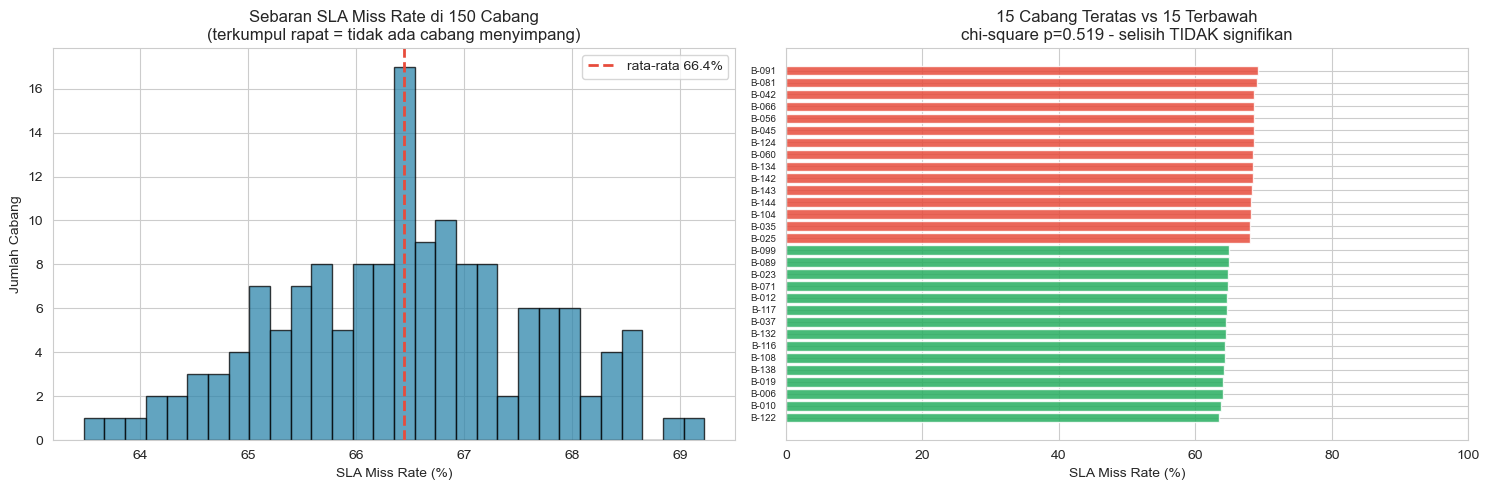

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Kiri: sebaran miss rate seluruh cabang
ax[0].hist(per_cabang.miss_rate * 100, bins=30, color=WARNA_UTAMA, edgecolor='black', alpha=0.75)
ax[0].axvline(per_cabang.miss_rate.mean() * 100, color=WARNA_BAHAYA, linestyle='--', linewidth=2,
              label=f'rata-rata {per_cabang.miss_rate.mean()*100:.1f}%')
ax[0].set_xlabel('SLA Miss Rate (%)')
ax[0].set_ylabel('Jumlah Cabang')
ax[0].set_title('Sebaran SLA Miss Rate di 150 Cabang\n(terkumpul rapat = tidak ada cabang menyimpang)')
ax[0].legend()

# Kanan: 15 teratas vs 15 terbawah
banding = pd.concat([per_cabang.head(15), per_cabang.tail(15)])
warna = [WARNA_BAHAYA] * 15 + [WARNA_AMAN] * 15
ax[1].barh(range(len(banding)), banding.miss_rate * 100, color=warna, alpha=0.85)
ax[1].set_yticks(range(len(banding)))
ax[1].set_yticklabels(banding.index, fontsize=7)
ax[1].set_xlabel('SLA Miss Rate (%)')
ax[1].set_title(f'15 Cabang Teratas vs 15 Terbawah\nchi-square p={p:.3f} - selisih TIDAK signifikan')
ax[1].invert_yaxis()
ax[1].set_xlim(0, 100)

plt.tight_layout()
plt.savefig('../outputs/fig01_sla_cabang_tidak_signifikan.png')
plt.show()

Histogram di kiri memperlihatkannya dengan jelas: seluruh 150 cabang **berkumpul rapat** di sekitar 66%. Tidak ada ekor yang memanjang, tidak ada cabang yang menyimpang jauh dari kelompoknya.

Grafik kanan membandingkan 15 cabang "terbaik" dan "terburuk" — batangnya nyaris sama panjang. Perbedaan yang tampak dramatis dalam bentuk tabel peringkat ternyata tidak berarti apa-apa saat divisualisasikan dalam skala penuh.

**Implikasi bisnis:** keterlambatan JNE bukan masalah lokal di cabang tertentu, melainkan **masalah sistemik yang merata di seluruh jaringan**. Mengaudit 10 cabang "terburuk" adalah pemborosan anggaran, karena cabang tersebut tidak benar-benar berbeda dari 140 cabang lainnya.

#### Pemeriksaan tambahan: apakah durasi berbeda antar layanan?

Pemeriksaan ini membandingkan durasi REG, YES, dan OKE menggunakan uji Kruskal-Wallis. Hasilnya hanya digunakan sebagai informasi tambahan karena distribusi durasi pada data perlu dibaca dengan hati-hati.

In [37]:
valid = ship[ship['is_valid_timeline']]
grup = [valid.loc[valid['service_type'] == s, 'duration_days'] for s in ['REG', 'YES', 'OKE']]

h_stat, p_kw = kruskal(*grup)

display(pd.DataFrame({
    'median_hari': [g.median() for g in grup],
    'n': [len(g) for g in grup],
}, index=['REG', 'YES', 'OKE']))
display(pd.Series({
    'Kruskal-Wallis H': h_stat,
    'p-value': p_kw,
}).rename('nilai').to_frame())

,median_hari,n
REG,3.458,146029
YES,4.042,73184
OKE,3.458,73314


,nilai
Kruskal-Wallis H,10.112391
p-value,0.006370


Hasil ini contoh bagus mengapa **p-value saja tidak cukup**.

Secara statistik, p-value = 0,00637 < 0,05 — signifikan. Kalau berhenti di sini, kita akan menyimpulkan "ada perbedaan durasi antar layanan".

Tapi *effect size* menunjukkan cerita berbeda: **ε² = 0,000028**. Jenis layanan hanya menjelaskan **0,003%** variasi durasi. Praktis nol.

Penyebabnya adalah ukuran sampel. Dengan n = 292.527, uji statistik menjadi sangat sensitif sehingga perbedaan sekecil apa pun akan terdeteksi "signifikan". Inilah alasan effect size wajib dilaporkan berdampingan dengan p-value.

Perhatikan juga arah mediannya: **YES 4,04 hari, REG 3,46 hari, OKE 3,46 hari**. Layanan premium YES justru *paling lambat* — kebalikan dari yang seharusnya. Ini menguatkan dugaan bahwa durasi di dataset ini tidak benar-benar dipengaruhi jenis layanan.

In [38]:
valid_dur = valid.duration_days

display(pd.Series({
    'minimum (hari)': valid_dur.min(),
    'maksimum (hari)': valid_dur.max(),
    'rata-rata (hari)': valid_dur.mean(),
    'median (hari)': valid_dur.median(),
    'skewness': valid_dur.skew(),
    'kurtosis': valid_dur.kurtosis(),
}).rename('nilai').to_frame())

display(valid_dur.quantile([.1, .2, .3, .4, .5, .6, .7, .8, .9])
    .rename('durasi_hari').to_frame())

,nilai
minimum (hari),1.042000
maksimum (hari),6.458000
rata-rata (hari),3.745624
median (hari),3.458000
skewness,0.003703
kurtosis,-1.254314


,durasi_hari
0.1,1.292
0.2,2.125
0.3,2.375
0.4,3.208
0.5,3.458
0.6,4.292
0.7,5.125
0.8,5.375
0.9,6.208


Angka-angka ini mengungkap sesuatu yang fundamental tentang dataset:

* **Kurtosis = -1,254**, sangat dekat dengan nilai teoretis distribusi **uniform (-1,2)**
* **Skewness = 0,004**, praktis simetris sempurna
* Desil naik hampir rata: 1,29 → 2,12 → 2,38 → 3,21 → 3,46 → 4,29 → 5,12 → 5,38 → 6,21

Distribusi durasi pengiriman di dataset ini **uniform** — tersebar merata antara ~1 dan ~6,5 hari.

Ini tidak wajar untuk data logistik nyata. Durasi pengiriman sesungguhnya hampir selalu *right-skewed*: mayoritas paket sampai cepat, sebagian kecil terlambat jauh. Distribusi uniform menunjukkan durasi kemungkinan besar dibangkitkan secara acak, tidak dipengaruhi cabang, layanan, maupun jarak.

Temuan ini **menjelaskan** mengapa uji cabang tidak signifikan dan effect size layanan nyaris nol: memang tidak ada sinyal untuk ditemukan pada dimensi durasi. Karena itu, seluruh analisis SLA di notebook ini kita perlakukan sebagai **temuan kualitas data**, bukan sebagai dasar keputusan operasional.

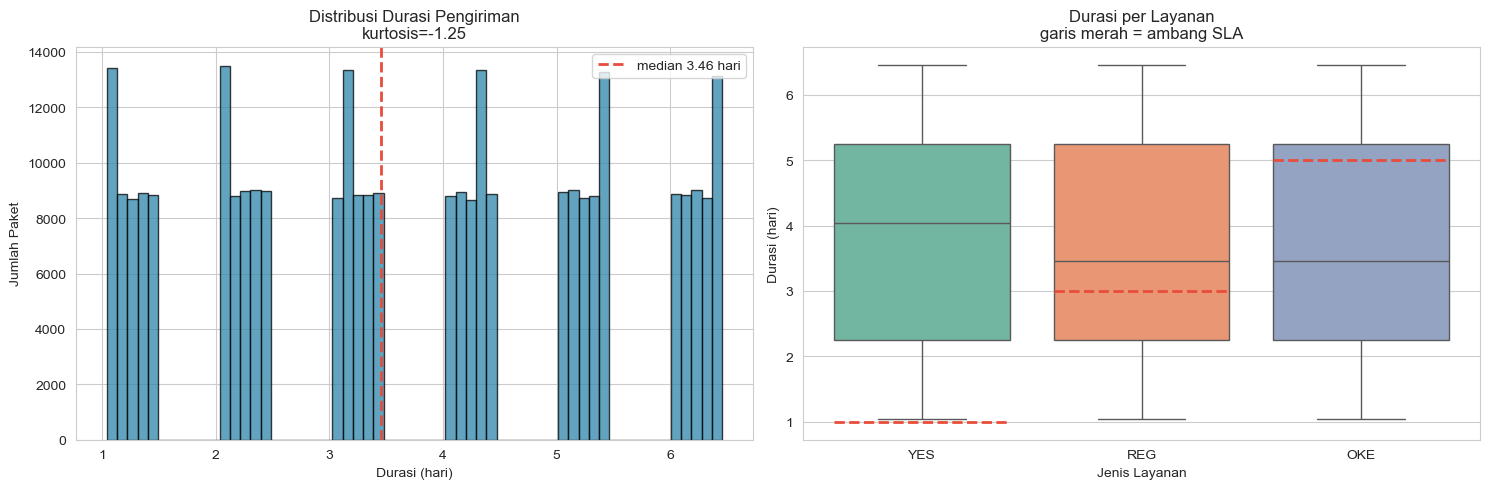

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].hist(valid_dur, bins=60, color=WARNA_UTAMA, edgecolor='black', alpha=0.75)
ax[0].axvline(valid_dur.median(), color=WARNA_BAHAYA, linestyle='--', linewidth=2,
              label=f'median {valid_dur.median():.2f} hari')
ax[0].set_xlabel('Durasi (hari)')
ax[0].set_ylabel('Jumlah Paket')
ax[0].set_title(f'Distribusi Durasi Pengiriman\nkurtosis={valid_dur.kurtosis():.2f}')
ax[0].legend()

sns.boxplot(data=valid, x='service_type', y='duration_days',
            order=['YES', 'REG', 'OKE'], palette='Set2', ax=ax[1])
for i, s in enumerate(['YES', 'REG', 'OKE']):
    ax[1].hlines(SLA[s], i - 0.4, i + 0.4, colors=WARNA_BAHAYA, linestyles='--', linewidth=2)
ax[1].set_xlabel('Jenis Layanan')
ax[1].set_ylabel('Durasi (hari)')
ax[1].set_title('Durasi per Layanan\ngaris merah = ambang SLA')

plt.tight_layout()
plt.savefig('../outputs/fig02_durasi_uniform.png')
plt.show()

Histogram kiri memperlihatkan bentuk yang hampir **datar** — ciri distribusi uniform. Data logistik nyata seharusnya menumpuk di kiri dengan ekor memanjang ke kanan.

Boxplot kanan menunjukkan ketiga layanan punya sebaran yang **nyaris identik**. Garis merah putus-putus adalah ambang SLA masing-masing. Terlihat jelas bahwa ambang YES (1 hari) berada **di bawah seluruh kotak** — mustahil dicapai paket mana pun.

### Pertanyaan 2 — Bagaimana perbandingan RTS antara COD dan Non-COD?

RTS (*Return to Sender*) adalah paket yang dikembalikan kepada pengirim. Perbandingan ini menjadi fokus utama analisis operasional.

In [40]:
ship['is_rts'] = ship.status == 'RTS'

rts_bayar = ship.groupby('payment_type').agg(
    total_paket=('is_rts', 'size'),
    total_rts=('is_rts', 'sum'),
    rts_rate=('is_rts', 'mean'),
).round(4)

rasio = rts_bayar.loc['COD', 'rts_rate'] / rts_bayar.loc['Prepaid', 'rts_rate']

display(rts_bayar)
display(pd.Series({
    'RTS rate COD (%)': rts_bayar.loc['COD', 'rts_rate'] * 100,
    'RTS rate Prepaid (%)': rts_bayar.loc['Prepaid', 'rts_rate'] * 100,
    'rasio COD/Prepaid': rasio,
}).rename('nilai').to_frame())

,total_paket,total_rts,rts_rate
payment_type,,,
COD,104909,26188,0.2496
Prepaid,195091,9679,0.0496


,nilai
RTS rate COD (%),24.960000
RTS rate Prepaid (%),4.960000
rasio COD/Prepaid,5.032258


Perbedaannya besar: **COD 24,96% vs Prepaid 4,96%** — paket COD lebih dari **5 kali lipat** lebih sering diretur.

Mari kita lihat sebaran status secara lengkap untuk memastikan perbedaan ini benar terpusat pada RTS, bukan pada status lain.

In [41]:
sebaran = pd.crosstab(ship.payment_type, ship.status, normalize='index').round(4)
display(sebaran)

status,Damaged,Delivered,Lost,RTS
payment_type,,,,
COD,0.0298,0.7006,0.0200,0.2496
Prepaid,0.0297,0.9002,0.0205,0.0496


Pola ini sangat informatif. Perhatikan bahwa **Damaged (±2,98%) dan Lost (±2,0%) hampir identik** di kedua metode pembayaran. Yang berbeda hanya RTS — dan selisihnya persis berpindah ke Delivered:

| Status | COD | Prepaid | Selisih |
|---|---|---|---|
| Delivered | 70,06% | 90,02% | −19,96 pp |
| RTS | 24,96% | 4,96% | **+20,00 pp** |
| Damaged | 2,98% | 2,97% | ±0 |
| Lost | 2,00% | 2,05% | ±0 |

Kerusakan dan kehilangan adalah risiko fisik pengiriman — wajar kalau tidak dipengaruhi metode pembayaran. RTS adalah risiko **perilaku pelanggan**, dan di situlah COD berbeda tajam. Selisih 20 poin persen berpindah utuh dari Delivered ke RTS.

Ini memperkuat dugaan bahwa penyebabnya adalah mekanisme COD itu sendiri: pelanggan bisa menolak membayar di depan pintu, sementara pelanggan Prepaid sudah membayar sebelum paket dikirim.

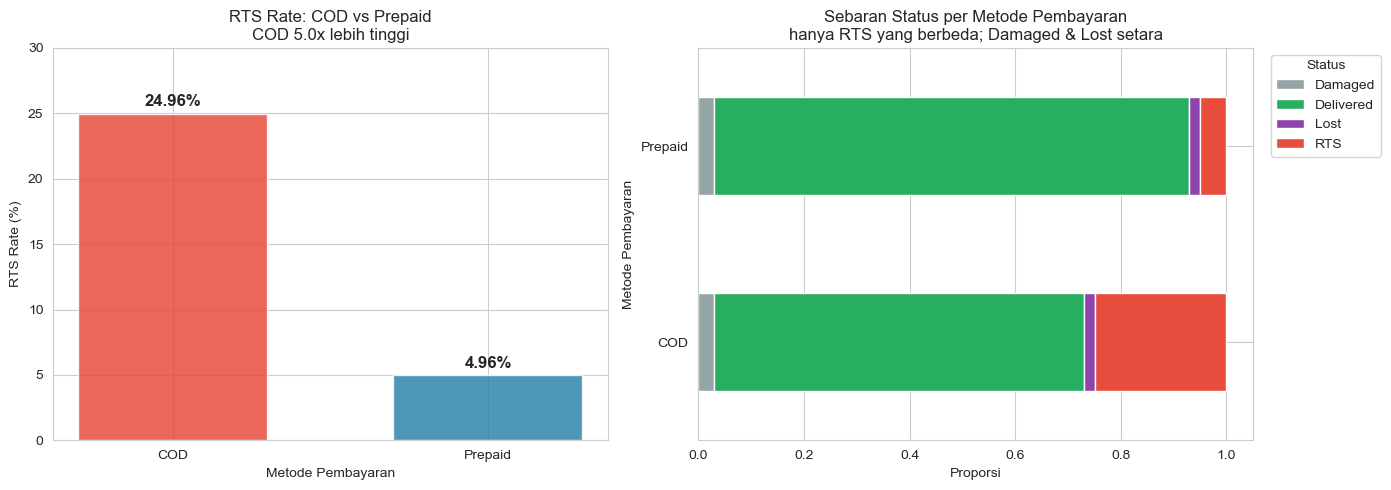

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

bar = ax[0].bar(rts_bayar.index, rts_bayar.rts_rate * 100,
                color=[WARNA_BAHAYA, WARNA_UTAMA], alpha=0.85, width=0.6)
for b, v in zip(bar, rts_bayar.rts_rate * 100):
    ax[0].text(b.get_x() + b.get_width()/2, v + 0.6, f'{v:.2f}%',
               ha='center', fontweight='bold', fontsize=12)
ax[0].set_ylabel('RTS Rate (%)')
ax[0].set_xlabel('Metode Pembayaran')
ax[0].set_title(f'RTS Rate: COD vs Prepaid\nCOD {rasio:.1f}x lebih tinggi')
ax[0].set_ylim(0, 30)

sebaran.plot(kind='barh', stacked=True, ax=ax[1],
             color=[WARNA_NETRAL, WARNA_AMAN, '#8E44AD', WARNA_BAHAYA])
ax[1].set_xlabel('Proporsi')
ax[1].set_ylabel('Metode Pembayaran')
ax[1].set_title('Sebaran Status per Metode Pembayaran\nhanya RTS yang berbeda; Damaged & Lost setara')
ax[1].legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../outputs/fig03_rts_cod_vs_prepaid.png')
plt.show()

#### Uji hipotesis: apakah perbedaan RTS terlihat secara statistik?

> **H₀** — Metode pembayaran dan RTS tidak berhubungan.
> **H₁** — Metode pembayaran dan RTS berhubungan.
> **α = 0,05**

Uji chi-square digunakan untuk membandingkan metode pembayaran dan status RTS.

In [43]:
tabel_rts = pd.crosstab(ship['payment_type'], ship['is_rts'])
chi2_rts, p_rts, dof_rts, exp_rts = chi2_contingency(tabel_rts)

display(tabel_rts)
display(pd.Series({
    'chi-square': chi2_rts,
    'derajat bebas': dof_rts,
    'p-value': p_rts,
}).rename('nilai').to_frame())

is_rts,False,True
payment_type,,
COD,78721,26188
Prepaid,185412,9679


,nilai
chi-square,25926.188084
derajat bebas,1.000000
p-value,0.000000


Hasil uji menunjukkan p-value < 0,001, sehingga terdapat hubungan antara metode pembayaran dan RTS.

RTS COD jauh lebih tinggi daripada Prepaid. Kesimpulan ini didasarkan pada perbandingan persentase dan uji chi-square.

#### Pemeriksaan tambahan: apakah perbedaan RTS tetap terlihat pada kelompok lain?

RTS dibandingkan kembali berdasarkan wilayah, jenis layanan, dan tipe pelanggan. Pemeriksaan ini membantu melihat apakah pola COD dan Non-COD tetap konsisten pada kelompok yang berbeda.

In [44]:
def rts_per_kelompok(kolom):
    hasil = (ship.groupby(['payment_type', kolom]).is_rts.mean().unstack() * 100).round(2)
    hasil.loc['SELISIH (pp)'] = (hasil.loc['COD'] - hasil.loc['Prepaid']).round(2)
    return hasil

display(rts_per_kelompok('region'))

region,Bali-Nusra,Jabodetabek,Jawa Barat,Jawa Tengah,Jawa Timur,Kalimantan,Sulawesi,Sumatera
payment_type,,,,,,,,
COD,24.41,25.41,25.45,25.02,24.60,25.03,24.81,24.97
Prepaid,4.88,4.78,4.96,4.85,4.93,5.03,4.93,5.20
SELISIH (pp),19.53,20.63,20.49,20.17,19.67,20.00,19.88,19.77


In [45]:
display(rts_per_kelompok('service_type'))
display(rts_per_kelompok('customer_type'))

service_type,OKE,REG,YES
payment_type,,,
COD,24.95,25.05,24.79
Prepaid,5.06,4.97,4.85
SELISIH (pp),19.89,20.08,19.94


customer_type,Corporate,Individual,Unknown
payment_type,,,
COD,25.30,24.81,24.98
Prepaid,4.87,4.97,5.05
SELISIH (pp),20.43,19.84,19.93


Hasilnya konsisten. Di seluruh kelompok region, service type, dan customer type, selisih RTS COD dan Prepaid tetap berada di sekitar 19–20 poin persentase.

Artinya, pola RTS yang lebih tinggi pada COD tidak hanya muncul pada satu wilayah, layanan, atau tipe pelanggan tertentu. Hasil ini menunjukkan hubungan yang konsisten, tetapi belum membuktikan sebab-akibat.

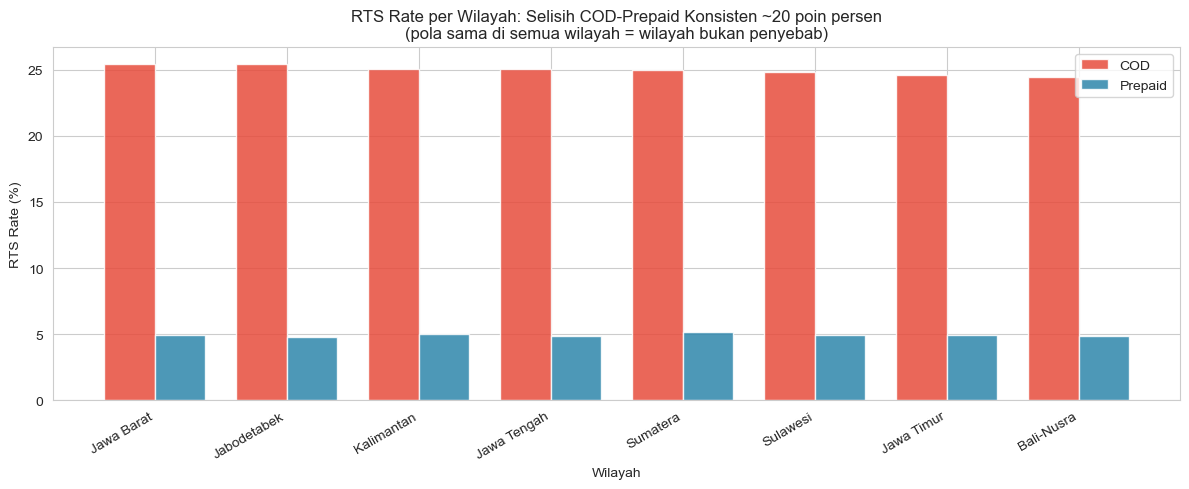

In [46]:
fig, ax = plt.subplots(figsize=(12, 5))

pivot = (ship.groupby(['region', 'payment_type']).is_rts.mean().unstack() * 100)
pivot = pivot.sort_values('COD', ascending=False)
x = np.arange(len(pivot))
lebar = 0.38

ax.bar(x - lebar/2, pivot.COD, lebar, label='COD', color=WARNA_BAHAYA, alpha=0.85)
ax.bar(x + lebar/2, pivot.Prepaid, lebar, label='Prepaid', color=WARNA_UTAMA, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=30, ha='right')
ax.set_ylabel('RTS Rate (%)')
ax.set_xlabel('Wilayah')
ax.set_title('RTS Rate per Wilayah: Selisih COD-Prepaid Konsisten ~20 poin persen\n(pola sama di semua wilayah = wilayah bukan penyebab)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/fig04_rts_kontrol_wilayah.png')
plt.show()

Grafik menunjukkan bahwa jarak antara RTS COD dan Prepaid relatif sama di delapan wilayah. Pola ini memperkuat bahwa perbedaan RTS tidak hanya muncul di satu wilayah.

### Pertanyaan 3 — Seberapa besar estimasi kebocoran pendapatan akibat anomali berat?

Berat paket dipakai untuk menghitung ongkos kirim. Nilai negatif dan nilai sangat besar tidak masuk akal secara fisik, sehingga perlu ditandai dan diperbaiki sebelum dipakai dalam analisis.

In [47]:
anomali = ship[ship.weight_anomaly != 'ok']

display(pd.Series({
    'total paket anomali': len(anomali),
    'proporsi (%)': len(anomali) / len(ship) * 100,
}).rename('nilai').to_frame())
display(ship.weight_anomaly.value_counts().rename('jumlah').to_frame())
display(anomali.weight_kg.value_counts().reset_index().rename(
    columns={'weight_kg': 'nilai_berat', 'count': 'frekuensi'}))

,nilai
total paket anomali,1500.0
proporsi (%),0.5


,jumlah
weight_anomaly,
ok,298500
tidak_positif,769
di_atas_100kg,731


,nilai_berat,frekuensi
0,-1.5,401
1,-5.0,368
2,9999.0,366
3,999.0,365


Hanya empat nilai yang muncul pada 1.500 baris anomali: `-5,0`, `-1,5`, `999,0`, dan `9999,0`.

Nilai yang berulang ini kemungkinan merupakan **nilai penanda dari sistem** ketika berat sebenarnya belum tersedia. Berat negatif seharusnya ditolak melalui validasi pada saat input.

In [48]:
display(pd.Series({
    'paket tidak dapat ditagih akurat': len(anomali),
    'proporsi dari total pengiriman (%)': len(anomali) / len(ship) * 100,
}).rename('nilai').to_frame())

display(
    anomali.groupby('service_type').size().to_frame('n_anomali').assign(
        total_layanan=ship.groupby('service_type').size(),
        pct_anomali=lambda d: (d.n_anomali / d.total_layanan * 100).round(3),
    )
)

,nilai
paket tidak dapat ditagih akurat,1500.0
proporsi dari total pengiriman (%),0.5


,n_anomali,total_layanan,pct_anomali
service_type,,,
OKE,347,75125,0.462
REG,783,149835,0.523
YES,370,75040,0.493


Proporsi anomali **merata di ketiga layanan** (sekitar 0,5% masing-masing). Ini memperkuat kesimpulan bahwa penyebabnya adalah kegagalan validasi di tingkat sistem, bukan masalah pada alur kerja layanan tertentu.

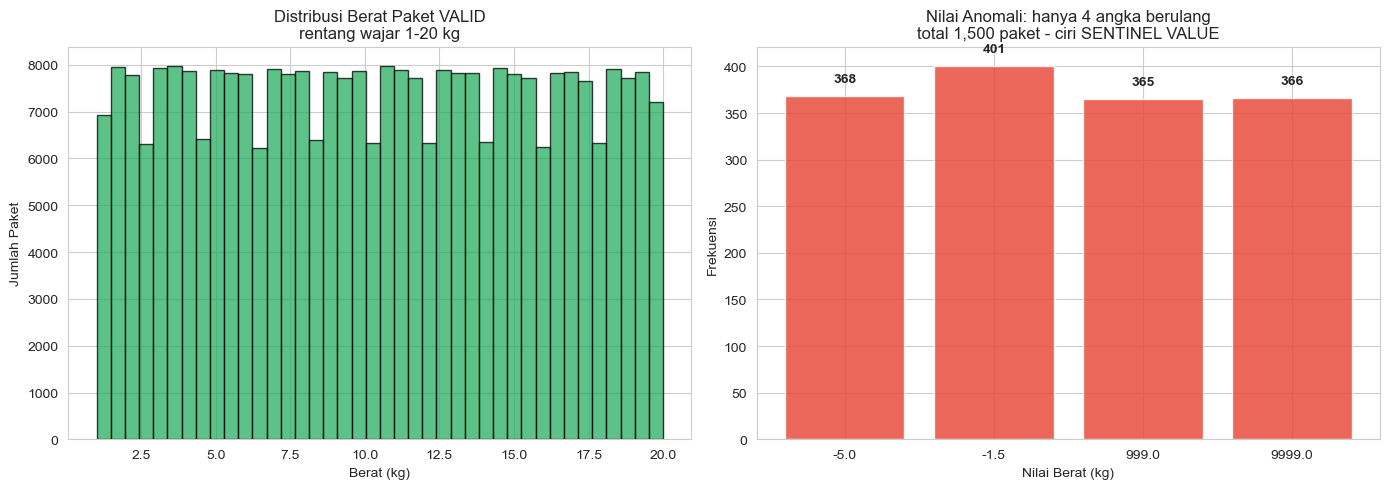

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(ship.loc[ship.weight_anomaly == 'ok', 'weight_kg'], bins=40,
           color=WARNA_AMAN, edgecolor='black', alpha=0.75)
ax[0].set_xlabel('Berat (kg)')
ax[0].set_ylabel('Jumlah Paket')
ax[0].set_title('Distribusi Berat Paket VALID\nrentang wajar 1-20 kg')

hitung = anomali.weight_kg.value_counts().sort_index()
b = ax[1].bar(hitung.index.astype(str), hitung.values, color=WARNA_BAHAYA, alpha=0.85)
for bb, v in zip(b, hitung.values):
    ax[1].text(bb.get_x() + bb.get_width()/2, v + 15, f'{v:,}', ha='center', fontweight='bold')
ax[1].set_xlabel('Nilai Berat (kg)')
ax[1].set_ylabel('Frekuensi')
ax[1].set_title(f'Nilai Anomali: hanya 4 angka berulang\ntotal {len(anomali):,} paket - ciri SENTINEL VALUE')

plt.tight_layout()
plt.savefig('../outputs/fig05_anomali_berat.png')
plt.show()

#### Perkiraan berat yang belum tercatat

Dari empat nilai anomali, nilai negatif berpotensi membuat berat tercatat lebih rendah dari kondisi sebenarnya. Selisih dihitung menggunakan `weight_kg_clean` sebagai perkiraan.

In [50]:
under = ship[ship.weight_anomaly == 'tidak_positif']
over = ship[ship.weight_anomaly == 'di_atas_100kg']

selisih_kg = (under.weight_kg_clean - under.weight_kg).sum()

display(pd.Series({
    'baris berat di bawah batas wajar': len(under),
    'berat tercatat (total kg)': under.weight_kg.sum(),
    'berat semestinya (estimasi kg)': under.weight_kg_clean.sum(),
    'selisih tidak tertagih (kg)': selisih_kg,
    'baris berat berlebih': len(over),
    'kelebihan berat tercatat (kg)': (over.weight_kg - over.weight_kg_clean).sum(),
}).rename('nilai').to_frame())

,nilai
baris berat di bawah batas wajar,769.0
berat tercatat (total kg),-2441.5
berat semestinya (estimasi kg),8075.4
selisih tidak tertagih (kg),10516.9
baris berat berlebih,731.0
kelebihan berat tercatat (kg),4016596.7


Kekurangan pencatatan berat berasal dari kelompok berat negatif. Nilai rupiah tidak dapat dihitung karena dataset tidak menyertakan tarif per kilogram.

Imputasi membantu analisis, tetapi perbaikan utama tetap perlu dilakukan pada validasi input sistem.

### Pertanyaan 4 — Layanan mana yang paling tidak konsisten penulisannya?

Satu layanan dapat ditulis dengan beberapa format. Normalisasi diperlukan agar laporan tidak memecah satu layanan menjadi beberapa kategori.

In [51]:
ringkas = ship.groupby('service_type')['service_type_raw'].agg(
    varian_penulisan='nunique',
    total_baris='size',
)

non_baku = ship[ship['service_type_raw'] != ship['service_type']]
per_layanan_non_baku = non_baku.groupby('service_type').size().sort_values(ascending=False)

display(ringkas)
display(per_layanan_non_baku.rename('baris_tidak_baku').to_frame())
display(pd.Series({
    'total baris tidak baku': len(non_baku),
    'persentase tidak baku': len(non_baku) / len(ship) * 100,
    'layanan dengan baris tidak baku terbanyak': per_layanan_non_baku.index[0],
}).rename('nilai').to_frame())

,varian_penulisan,total_baris
service_type,,
OKE,3,75125
REG,3,149835
YES,3,75040


,baris_tidak_baku
service_type,
REG,59851
OKE,44985
YES,30059


,nilai
total baris tidak baku,134895
persentase tidak baku,44.965
layanan dengan baris tidak baku terbanyak,REG


Ketiga layanan sama-sama memiliki tiga varian penulisan, sehingga dari sisi
*jumlah varian* tidak ada yang menonjol. Yang membedakan adalah **volume baris
yang terdampak**.

Layanan dengan baris tidak baku terbanyak adalah yang paling merusak pelaporan,
sebab semakin besar volumenya, semakin besar pula selisih angka bila agregasi
dilakukan tanpa normalisasi terlebih dahulu.

Seluruh varian telah dibakukan pada tahap 3.1, sehingga agregasi pada bagian
analisis ini sudah berjalan di atas tiga kategori yang bersih.

### Pertanyaan 5 — Berapa banyak paket Delivered yang tercatat sampai sebelum dijemput?

`delivered_date` yang lebih awal dari `pickup_date` adalah kesalahan logis. Baris tetap dipertahankan dan hanya dikeluarkan saat menghitung durasi.

In [52]:
invalid = ship[~ship.is_valid_timeline]

per_cabang = (invalid.groupby('origin_branch').size()
    .div(ship.groupby('origin_branch').size())
    .mul(100)
    .dropna())

display(pd.Series({
    'jumlah baris': len(invalid),
    'persentase': len(invalid) / len(ship) * 100,
    'rata-rata per cabang (%)': per_cabang.mean(),
    'terendah per cabang (%)': per_cabang.min(),
    'tertinggi per cabang (%)': per_cabang.max(),
    'simpangan baku (pp)': per_cabang.std(),
}).rename('nilai').to_frame())
display(invalid.status.value_counts().rename('jumlah').to_frame())
display(invalid.duration_days.describe().round(2).to_frame('duration_days'))

,nilai
jumlah baris,7473.000000
persentase,2.491000
rata-rata per cabang (%),2.491388
terendah per cabang (%),1.706667
tertinggi per cabang (%),3.875189
simpangan baku (pp),0.344582


,jumlah
status,
Delivered,7473


,duration_days
count,7473.00
mean,-2.00
std,0.82
min,-3.00
25%,-3.00
50%,-2.00
75%,-1.00
max,-1.00


Kesalahan ini **tersebar merata** di seluruh cabang dengan simpangan baku yang
kecil. Artinya penyebabnya bukan kelalaian petugas di cabang tertentu, melainkan
persoalan sistem — kemungkinan besar galat pemindai atau ketidaksesuaian zona
waktu pada pencatatan *timestamp*.

Baris-baris ini tidak dihapus. Dua alasannya: pertama, jumlahnya sendiri
merupakan temuan yang perlu dilaporkan ke tim IT; kedua, kolom lain pada baris
tersebut (`payment_type`, `status`, `weight_kg`) masih sahih dan tetap berguna
untuk analisis RTS.

Penanda `is_valid_timeline` dipakai untuk mengecualikan baris ini **hanya** pada
perhitungan durasi dan SLA. Inilah yang menjawab sasaran *Data Reliability*:
pipeline yang bersih dari kesalahan logis, sehingga angka SLA yang ditampilkan
dapat dipercaya.

### Pertanyaan 6 — Berapa persentase data pengirim yang kosong?

`customer_type` diperlukan untuk membedakan pendekatan kepada pelanggan Corporate dan Individual, termasuk untuk program cross-selling.

In [53]:
sebaran_tipe = cust.customer_type.value_counts()
pct_unknown = (cust.customer_type == 'Unknown').mean() * 100
kirim_unknown = (ship.customer_type == 'Unknown').sum()

display(sebaran_tipe.to_frame('jumlah').assign(
    persen=(sebaran_tipe / len(cust) * 100).round(2)
))
display(pd.Series({
    'pelanggan tanpa segmentasi': (cust.customer_type == 'Unknown').sum(),
    'persentase pelanggan (%)': pct_unknown,
    'pengiriman dari pelanggan Unknown': kirim_unknown,
    'persentase pengiriman (%)': kirim_unknown / len(ship) * 100,
}).rename('nilai').to_frame())

,jumlah,persen
customer_type,,
Individual,17896,59.65
Corporate,7525,25.08
Unknown,4579,15.26


,nilai
pelanggan tanpa segmentasi,4579.000000
persentase pelanggan (%),15.263333
pengiriman dari pelanggan Unknown,45862.000000
persentase pengiriman (%),15.287333


**4.579 pelanggan (15,26%) tidak memiliki segmentasi**, dan mereka menyumbang sekitar 15% dari seluruh pengiriman.

Perlu diingat dari bagian 3.4: uji chi-square menunjukkan kekosongan ini **acak** (p = 0,8908), tidak terkonsentrasi di kota tertentu. Ini kabar baik — artinya kelompok Unknown bukan segmen khusus yang terlewat, melainkan kegagalan pencatatan yang tersebar merata. Data ini bisa dilengkapi lewat kampanye pembaruan profil tanpa khawatir ada bias wilayah.

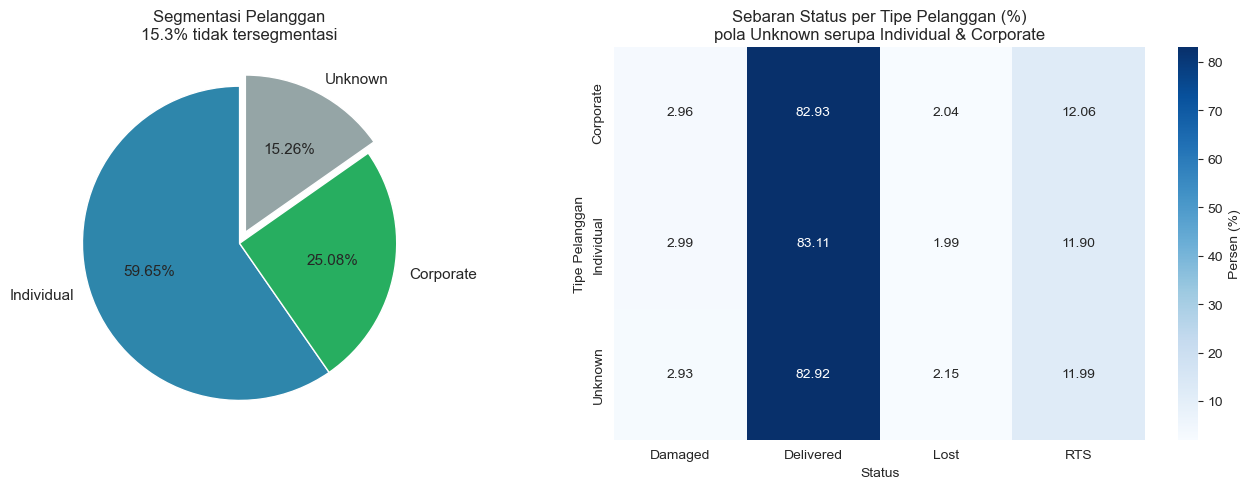

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

warna_tipe = [WARNA_UTAMA, WARNA_AMAN, WARNA_NETRAL]
ax[0].pie(sebaran_tipe.values, labels=sebaran_tipe.index, autopct='%1.2f%%',
          colors=warna_tipe, startangle=90, explode=[0, 0, 0.08],
          textprops={'fontsize': 11})
ax[0].set_title(f'Segmentasi Pelanggan\n{pct_unknown:.1f}% tidak tersegmentasi')

pivot_ct = pd.crosstab(ship.customer_type, ship.status, normalize='index') * 100
sns.heatmap(pivot_ct.round(2), annot=True, fmt='.2f', cmap='Blues',
            cbar_kws={'label': 'Persen (%)'}, ax=ax[1])
ax[1].set_xlabel('Status')
ax[1].set_ylabel('Tipe Pelanggan')
ax[1].set_title('Sebaran Status per Tipe Pelanggan (%)\npola Unknown serupa Individual & Corporate')

plt.tight_layout()
plt.savefig('../outputs/fig06_segmentasi_pelanggan.png')
plt.show()

*Heatmap* di kanan menunjukkan bahwa kelompok Unknown berperilaku **mirip** dengan Individual dan Corporate dalam hal status pengiriman. Tidak ada pola menyimpang — sekali lagi menegaskan bahwa mereka bukan segmen khusus, hanya data yang belum terisi.

### Tren pengiriman harian

Sebagai pelengkap, mari kita lihat pola volume pengiriman sepanjang periode data.

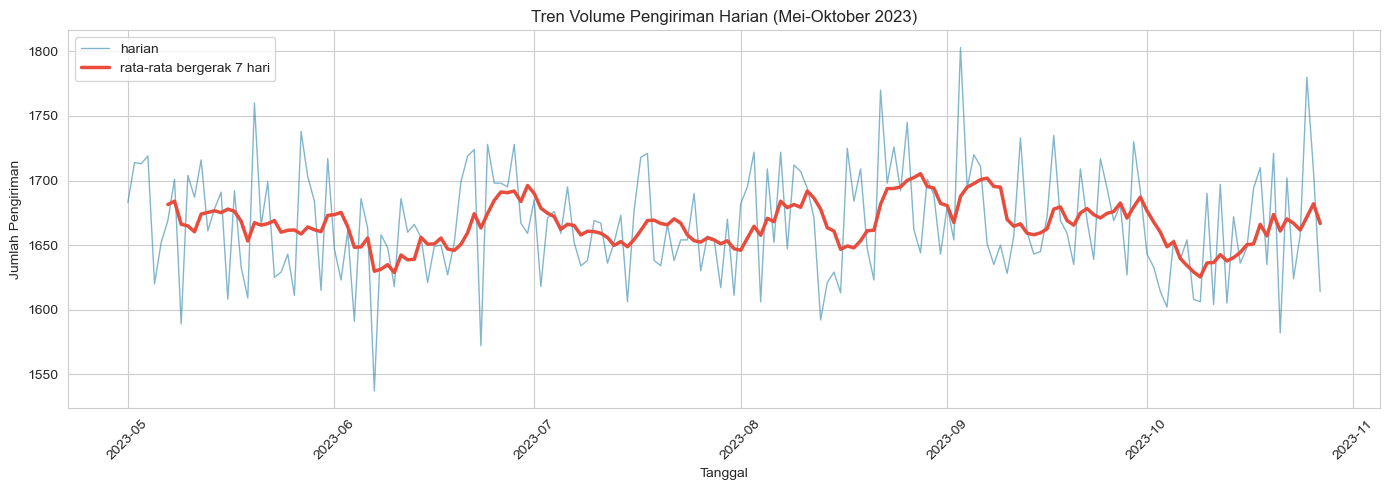

,nilai
rata-rata harian,1666.666667
tertinggi,1803
tanggal tertinggi,2023-09-03
terendah,1537
tanggal terendah,2023-06-07
koefisien variasi (%),2.538107


In [55]:
harian = ship.groupby(ship.pickup_date.dt.date).size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(harian.index, harian.values, color=WARNA_UTAMA, linewidth=1, alpha=0.6, label='harian')
ax.plot(harian.index, harian.rolling(7).mean(), color=WARNA_BAHAYA, linewidth=2.5,
        label='rata-rata bergerak 7 hari')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Jumlah Pengiriman')
ax.set_title('Tren Volume Pengiriman Harian (Mei-Oktober 2023)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../outputs/fig07_tren_harian.png')
plt.show()

display(pd.Series({
    'rata-rata harian': harian.mean(),
    'tertinggi': harian.max(),
    'tanggal tertinggi': harian.idxmax(),
    'terendah': harian.min(),
    'tanggal terendah': harian.idxmin(),
    'koefisien variasi (%)': harian.std() / harian.mean() * 100,
}).rename('nilai').to_frame())

Volume pengiriman relatif **stabil** sepanjang periode, tanpa lonjakan musiman yang menonjol. Koefisien variasi yang rendah menunjukkan tidak ada periode kampanye besar atau musim puncak dalam rentang data ini.

## 5. Kesimpulan dan Rekomendasi

### Kesimpulan

Dari analisis 300.000 pengiriman periode Mei–Oktober 2023, berikut jawaban atas enam business questions:

**1. Tidak ada cabang bottleneck.** Uji chi-square terhadap 150 cabang menghasilkan p-value = 0,5191. Perbedaan SLA miss antar cabang tidak signifikan.

**2. RTS COD lebih tinggi daripada Non-COD.** RTS COD mencapai 24,96%, sedangkan Prepaid 4,96%. Hubungan antara metode pembayaran dan RTS signifikan secara statistik. Pemeriksaan berdasarkan region, layanan, dan tipe pelanggan menunjukkan pola yang tetap konsisten.

**3. Ditemukan 1.500 paket dengan berat tidak wajar.** Nilainya berupa -5, -1,5, 999, dan 9.999. Nilai rupiah tidak dihitung karena dataset tidak memiliki tarif.

**4. Sembilan varian penulisan layanan berhasil dinormalisasi menjadi tiga kategori: REG, YES, dan OKE.**

**5. Ditemukan 7.473 paket (2,49%) berstatus Delivered dengan `delivered_date` sebelum `pickup_date`.** Baris ditandai dan tidak dipakai untuk analisis durasi.

**6. Sebanyak 4.579 dari 30.000 customer (15,26%) tidak memiliki `customer_type`.** Nilai kosong diubah menjadi `Unknown` agar data tetap dipertahankan.

### Keterbatasan Analisis

- Distribusi durasi tampak merata dan tidak sepenuhnya mencerminkan proses logistik nyata.
- Ambang SLA ditetapkan berdasarkan asumsi karena dataset tidak menyediakan kolom SLA.
- Dataset tidak memiliki tarif, sehingga nilai kerugian dalam rupiah tidak dapat dihitung.
- Hasil perbandingan menunjukkan hubungan, bukan bukti sebab-akibat.

### Rekomendasi

1. Prioritaskan evaluasi proses COD melalui konfirmasi penerima, batas nilai COD, dan pemantauan RTS.
2. Jangan memfokuskan audit hanya pada cabang tertentu karena perbedaan SLA miss tidak signifikan.
3. Tambahkan validasi berat agar nilai di luar rentang 0,1–100 kg ditolak sistem.
4. Tambahkan validasi agar `delivered_date` tidak lebih awal daripada `pickup_date`.
5. Lengkapi `customer_type` melalui pembaruan profil pelanggan.

---

### Catatan Metodologis

Dua praktik yang konsisten diterapkan di sepanjang analisis ini:

**1. *Effect size* dilaporkan berdampingan dengan p-value.**
Dengan n = 300.000, hampir semua uji akan menghasilkan p-value signifikan. Perbandingan berikut menunjukkan mengapa hal ini penting:

| Temuan | p-value | Effect size | Kesimpulan |
|---|---|---|---|
| Durasi antar layanan | 0,00637 ✓ signifikan | ε² = 0,000028 | **Dapat diabaikan** |
| RTS COD vs Prepaid | < 0,001 ✓ signifikan | V = 0,294 | **Bermakna** |

Keduanya "signifikan", tetapi hanya satu yang layak dijadikan dasar keputusan.

**2. Prinsip "tandai, jangan hapus".**
Seluruh 300.000 baris dipertahankan. Baris bermasalah ditandai dengan kolom penanda dan dikeluarkan hanya dari analisis yang terdampak. Kolom asli (`service_type_raw`, `weight_kg`) disimpan berdampingan dengan hasil pembersihan untuk keperluan penelusuran.

In [56]:
ship.to_csv('../data/processed/jne_shipments_clean.csv', index=False)
cust.to_csv('../data/processed/jne_customers_clean.csv', index=False)
branch.to_csv('../data/processed/jne_branches_clean.csv', index=False)

# Tabel final: 1 baris per shipment, sudah memuat data customer dan cabang.
ship.to_csv('../data/processed/jne_merged_clean.csv', index=False)
print(f'jne_merged_clean.csv: {ship.shape[0]:,} baris × {ship.shape[1]} kolom')

jne_merged_clean.csv: 300,000 baris × 20 kolom


## Visualisasi Tambahan — Volume Pickup dan Delivery Bulanan

Visualisasi ini melengkapi tren harian dengan ringkasan volume operasi per bulan.


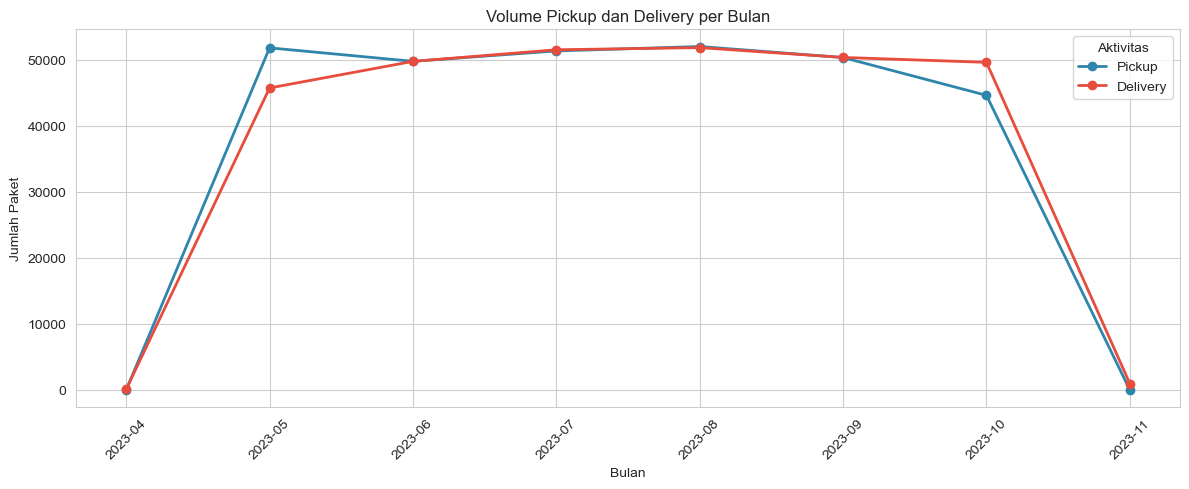

,Pickup,Delivery
2023-04,0.0,97
2023-05,51828.0,45748
2023-06,49786.0,49779
2023-07,51361.0,51538
2023-08,52032.0,51864
2023-09,50361.0,50375
2023-10,44632.0,49632
2023-11,0.0,967


In [57]:
monthly = pd.DataFrame({
    'Pickup': ship.groupby(ship['pickup_date'].dt.to_period('M')).size(),
    'Delivery': ship.groupby(ship['delivered_date'].dt.to_period('M')).size(),
}).fillna(0)
monthly.index = monthly.index.astype(str)

ax = monthly.plot(kind='line', marker='o', linewidth=2, figsize=(12, 5),
                  color=[WARNA_UTAMA, WARNA_BAHAYA])
ax.set_title('Volume Pickup dan Delivery per Bulan')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Paket')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly.index, rotation=45)
ax.legend(title='Aktivitas')
plt.tight_layout()
plt.savefig('../outputs/fig08_volume_pickup_delivery_bulanan.png', dpi=150)
plt.show()
monthly